# Comparaison de deux reftables DIYABC
Structure attendue : `scenario | 7 priors | 50 stats` (152 colonnes + header)

In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

NOTEBOOK_DIR = Path.cwd()
print(f"NOTEBOOK_DIR : {NOTEBOOK_DIR}")

ROOT_DIR = Path.cwd().parent.parent
print(f"ROOT_DIR : {ROOT_DIR}")

sys.path.insert(0, str(ROOT_DIR))
from bridge.prior_parser import parse_priors  # noqa: E402
from bridge.reftable_loop import rewrite_real_reftable_txt  # noqa: E402
from bridge.scenario_parser import parse_header_scenarios  # noqa: E402

In [43]:
# ── À MODIFIER ────────────────────────────────────────────────────────────────
FILE_diy = Path(NOTEBOOK_DIR / "first_records_of_the_reference_table_0.txt")
FILE_msprime = Path(
    NOTEBOOK_DIR / "reftable_msprime_replay.txt"
)  # ex: sortie pipeline Python
LABEL_diy = "C++ (référence)"
LABEL_msprime = "Python (msprime)"
SEP = r"\s+"  # séparateur : ' ', '\t', ','
N_PRIORS = 7
N_STATS = 50
# ──────────────────────────────────────────────────────────────────────────────

## 1. Chargement

In [59]:
df_msprime = pd.read_csv(FILE_msprime, sep=SEP)

with open(header_file := Path(NOTEBOOK_DIR / "headerRF.txt")) as f:
    header_text = f.read()
priors, _constraints = parse_priors(header_text)
scenarios = parse_header_scenarios(header_text)

rewrite_real_reftable_txt(
    "first_records_of_the_reference_table_0.txt",  # brut (cases vides)
    "first_records_clean.txt",  # nettoyé (nan)
    priors,
    scenarios,
)

df_diy = pd.read_csv("first_records_clean.txt", sep=SEP)


print(f"{LABEL_diy} : {df_diy.shape}")
print(f"{LABEL_msprime} : {df_msprime.shape}")
print(f"Colonnes : {df_diy.columns.tolist()}")
print(f"Colonnes : {df_msprime.columns.tolist()}")

C++ (référence) : (1000, 58)
Python (msprime) : (1000, 58)
Colonnes : ['scenario', 'N1', 'N2', 'N3', 'ta', 'ts', 'N4', 'r', 'ML1p_1', 'ML1p_2', 'ML1p_3', 'ML2p_1.2', 'ML2p_1.3', 'ML2p_2.3', 'HWm_1', 'HWm_2', 'HWm_3', 'HWv_1', 'HWv_2', 'HWv_3', 'HBm_1.2', 'HBm_1.3', 'HBm_2.3', 'HBv_1.2', 'HBv_1.3', 'HBv_2.3', 'FST1m_1', 'FST1m_2', 'FST1m_3', 'FST1v_1', 'FST1v_2', 'FST1v_3', 'FST2m_1.2', 'FST2m_1.3', 'FST2m_2.3', 'FST2v_1.2', 'FST2v_1.3', 'FST2v_2.3', 'NEIm_1.2', 'NEIm_1.3', 'NEIm_2.3', 'NEIv_1.2', 'NEIv_1.3', 'NEIv_2.3', 'AMLm_1.2.3', 'AMLm_2.1.3', 'AMLm_3.1.2', 'AMLv_1.2.3', 'AMLv_2.1.3', 'AMLv_3.1.2', 'FST3m_1.2.3', 'FST3v_1.2.3', 'F3m_1.2.3', 'F3m_2.1.3', 'F3m_3.1.2', 'F3v_1.2.3', 'F3v_2.1.3', 'F3v_3.1.2']
Colonnes : ['scenario', 'N1', 'N2', 'N3', 'ta', 'ts', 'N4', 'r', 'ML1p_1', 'ML1p_2', 'ML1p_3', 'ML2p_1.2', 'ML2p_1.3', 'ML2p_2.3', 'HWm_1', 'HWm_2', 'HWm_3', 'HWv_1', 'HWv_2', 'HWv_3', 'HBm_1.2', 'HBm_1.3', 'HBm_2.3', 'HBv_1.2', 'HBv_1.3', 'HBv_2.3', 'FST1m_1', 'FST1m_2', 'FST1m_3'

In [60]:
# Vérification et alignement des colonnes
cols_diy = set(df_diy.columns)
cols_msprime = set(df_msprime.columns)

only_in_diy = cols_diy - cols_msprime
only_in_msprime = cols_msprime - cols_diy

if only_in_diy or only_in_msprime:
    print("⚠️  Headers différents :")
    if only_in_diy:
        print(
            f"   Uniquement dans {LABEL_diy}     ({len(only_in_diy)}) : {sorted(only_in_diy)}"
        )
    if only_in_msprime:
        print(
            f"   Uniquement dans {LABEL_msprime} ({len(only_in_msprime)}) : {sorted(only_in_msprime)}"
        )
else:
    print("✅ Headers identiques")

✅ Headers identiques


In [ ]:
# Intersection ordonnée selon df_diy (référence)
col_keep = [c for c in df_diy.columns if c in cols_msprime]
df_diy = df_diy[col_keep]
df_msprime = df_msprime[col_keep]

n_dropped = len(cols_diy | cols_msprime) - len(col_keep) * 2 // 2
if n_dropped:
    print(f"   → {n_dropped} colonne(s) exclue(s), {len(col_keep)} conservée(s)")

# Découpage groupes
col_scenario = df_diy.columns[0]
col_priors = list(df_diy.columns[1 : 1 + N_PRIORS])
col_stats = list(df_diy.columns[1 + N_PRIORS : 1 + N_PRIORS + N_STATS])
col_all = col_priors + col_stats

print(f"\nScénario : {col_scenario}")
print(f"Priors   : {col_priors[:3]} … ({len(col_priors)} total)")
print(f"Stats    : {col_stats[:3]} … ({len(col_stats)} total)")

priors_msg = f"Attendu {N_PRIORS} priors, trouvé {len(col_priors)}"
assert len(col_priors) == N_PRIORS, priors_msg
stats_msg = f"Attendu {N_STATS} stats, trouvé {len(col_stats)}"
assert len(col_stats) == N_STATS, stats_msg

In [62]:
df_diy

,scenario,N1,N2,N3,ta,ts,N4,r,ML1p_1,ML1p_2,...,AMLv_2.1.3,AMLv_3.1.2,FST3m_1.2.3,FST3v_1.2.3,F3m_1.2.3,F3m_2.1.3,F3m_3.1.2,F3v_1.2.3,F3v_2.1.3,F3v_3.1.2
0,1,16560.0,26512.0,13037.0,2430.0,25625.0,20778.0,NaN,0.650769,0.504615,...,0.249143,0.152215,0.434674,0.079506,0.004411,0.123105,0.004416,0.001622,0.071619,0.002144
1,1,22418.0,13709.0,25113.0,2392.0,25016.0,18157.0,NaN,0.516923,0.667692,...,0.246551,0.182195,0.366265,0.057597,0.009700,0.099132,0.000732,0.003632,0.047600,0.002616
2,1,13493.0,5111.0,12180.0,10564.0,26185.0,1897.0,NaN,0.590769,0.813846,...,0.250511,0.240988,0.538767,0.098916,0.032847,0.103491,0.028132,0.019715,0.072857,0.015906
3,2,7626.0,9608.0,6515.0,27839.0,29234.0,18439.0,NaN,0.756923,0.676923,...,0.245041,0.247714,0.753726,0.159476,0.116504,0.083895,0.135236,0.085931,0.062423,0.102491
4,3,3005.0,16125.0,9263.0,21826.0,26850.0,16723.0,0.062,0.906154,0.540000,...,0.224269,0.226054,0.690873,0.145890,0.126283,0.071283,0.084329,0.095142,0.054360,0.057109
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1,26266.0,15051.0,10235.0,13342.0,20166.0,3611.0,NaN,0.546154,0.696923,...,0.237338,0.245759,0.415170,0.066402,0.018686,0.048062,0.034019,0.011872,0.030524,0.020708
996,2,20656.0,29718.0,5647.0,9023.0,21669.0,192.0,NaN,0.658462,0.529231,...,0.216421,0.246494,0.376058,0.054290,0.033456,0.013269,0.030076,0.021449,0.007531,0.019494
997,3,27171.0,8895.0,28980.0,22922.0,29215.0,12663.0,0.136,0.596923,0.810769,...,0.247680,0.221231,0.481527,0.085457,0.059029,0.054909,0.024041,0.037640,0.034510,0.018539
998,3,25424.0,6835.0,10539.0,18045.0,29938.0,2897.0,0.634,0.504615,0.816923,...,0.236512,0.216780,0.486019,0.081795,0.031501,0.052527,0.049003,0.012475,0.037626,0.036240


In [63]:
df_msprime

,scenario,N1,N2,N3,ta,ts,N4,r,ML1p_1,ML1p_2,...,AMLv_2.1.3,AMLv_3.1.2,FST3m_1.2.3,FST3v_1.2.3,F3m_1.2.3,F3m_2.1.3,F3m_3.1.2,F3v_1.2.3,F3v_2.1.3,F3v_3.1.2
0,1,16560.0,26512.0,13037.0,2430.0,25625.0,20778.0,NaN,0.610769,0.470769,...,0.243215,0.173029,0.332456,0.056031,0.007204,0.086546,0.004450,0.002191,0.047477,0.001891
1,1,22418.0,13709.0,25113.0,2392.0,25016.0,18157.0,NaN,0.544615,0.658462,...,0.246967,0.177655,0.380300,0.071726,0.004954,0.114231,0.003975,0.001806,0.064970,0.002857
2,1,13493.0,5111.0,12180.0,10564.0,26185.0,1897.0,NaN,0.607692,0.820000,...,0.249830,0.237442,0.493639,0.080709,0.025929,0.078579,0.028359,0.015075,0.054167,0.011908
3,2,7626.0,9608.0,6515.0,27839.0,29234.0,18439.0,NaN,0.733846,0.680000,...,0.239276,0.246393,0.741078,0.159893,0.132500,0.108237,0.096283,0.094425,0.080114,0.072724
4,3,3005.0,16125.0,9263.0,21826.0,26850.0,16723.0,0.062,0.898462,0.506154,...,0.231670,0.214476,0.662955,0.131673,0.113755,0.066083,0.075579,0.081933,0.044666,0.050895
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1,26266.0,15051.0,10235.0,13342.0,20166.0,3611.0,NaN,0.572308,0.666154,...,0.237576,0.245382,0.332838,0.049997,0.012647,0.039807,0.022839,0.005689,0.024339,0.012781
996,2,20656.0,29718.0,5647.0,9023.0,21669.0,192.0,NaN,0.640000,0.549231,...,0.209734,0.249379,0.358624,0.055821,0.031450,0.014847,0.031716,0.022035,0.007968,0.022661
997,3,27171.0,8895.0,28980.0,22922.0,29215.0,12663.0,0.136,0.563077,0.836923,...,0.244313,0.201618,0.488844,0.086224,0.063483,0.052366,0.023953,0.043318,0.034142,0.015178
998,3,25424.0,6835.0,10539.0,18045.0,29938.0,2897.0,0.634,0.524615,0.830769,...,0.239075,0.211096,0.502389,0.088543,0.045032,0.054096,0.038066,0.032996,0.038271,0.022010


## 2. Statistiques descriptives

In [69]:
def describe_df(df, cols, label, scenario: int):
    df = df[df["scenario"] == scenario]
    d = (
        df[cols]
        .describe(
            percentiles=[0.05, 0.25, 0.5, 0.75, 0.95],
        )
        .T
    )
    d.columns = [f"{label}_{c}" for c in d.columns]
    return d


scenario = 3

desc_diy = describe_df(df_diy, col_all, "diy", scenario)
desc_msprime = describe_df(df_msprime, col_all, "msprime", scenario)
desc = pd.concat([desc_diy, desc_msprime], axis=1)

# Colonnes pratiques pour comparaison
for stat in ["mean", "std", "50%"]:
    desc[f"diff_{stat}"] = desc[f"msprime_{stat}"] - desc[f"diy_{stat}"]
    desc[f"rdiff_{stat}"] = (
        desc[f"diff_{stat}"] / (desc[f"diy_{stat}"].abs() + 1e-12)
    ) * 100

desc[
    [
        "diy_mean",
        "msprime_mean",
        "diff_mean",
        "rdiff_mean",
        "diy_std",
        "msprime_std",
        "diff_std",
        "diy_50%",
        "msprime_50%",
        "diff_50%",
    ]
].round(4)

,diy_mean,msprime_mean,diff_mean,rdiff_mean,diy_std,msprime_std,diff_std,diy_50%,msprime_50%,diff_50%
N1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
N2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
N3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ta,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ts,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
N4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
r,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ML1p_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ML1p_2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ML1p_3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [65]:
# Colonnes avec écart relatif sur la moyenne > seuil
THRESHOLD_PCT = 5.0
flagged = desc[desc["rdiff_mean"].abs() > THRESHOLD_PCT][
    ["diy_mean", "msprime_mean", "rdiff_mean"]
]
print(f"Colonnes avec |écart relatif mean| > {THRESHOLD_PCT}% : {len(flagged)}")
flagged.sort_values("rdiff_mean", key=abs, ascending=False).round(4)

Colonnes avec |écart relatif mean| > 5.0% : 18


,diy_mean,msprime_mean,rdiff_mean
F3v_3.1.2,0.0177,0.0160,-9.5084
F3m_3.1.2,0.0282,0.0259,-8.3796
FST1v_3,0.6870,0.7349,6.9697
NEIv_1.3,0.0843,0.0787,-6.6120
F3v_1.2.3,0.0633,0.0593,-6.3563
FST2m_2.3,0.3254,0.3050,-6.2882
NEIv_2.3,0.0331,0.0310,-6.1900
F3m_1.2.3,0.1036,0.0973,-6.0892
NEIm_1.3,0.1414,0.1328,-6.0627
FST2v_2.3,0.0541,0.0509,-5.9495


## 3. Test Kolmogorov-Smirnov colonne par colonne

In [ ]:
df_diy_scenario = df_diy[df_diy["scenario"] == scenario].copy()
df_msprime_scenario = df_msprime[df_msprime["scenario"] == scenario].copy()
ks_results = []
for col in col_all:
    diy_vals = df_diy_scenario[col].dropna().values
    msprime_vals = df_msprime_scenario[col].dropna().values
    stat_ks, pval = stats.ks_2samp(diy_vals, msprime_vals)
    ks_results.append({"column": col, "ks_stat": stat_ks, "p_value": pval})

ks_df = (
    pd.DataFrame(ks_results).set_index("column").sort_values("ks_stat", ascending=False)
)

print(
    f"Colonnes avec p-value KS < 0.05 : {(ks_df.p_value < 0.05).sum()} / {len(ks_df)}"
)
ks_df.round(4)

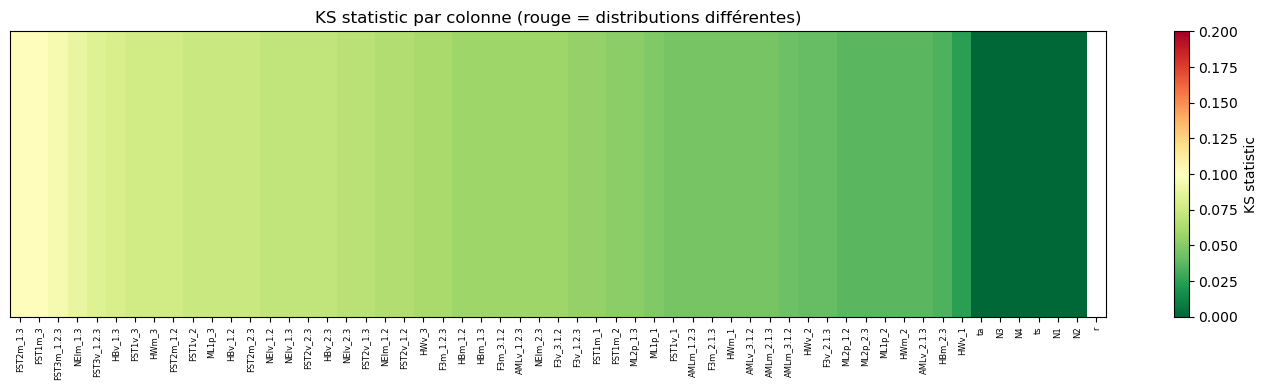

In [67]:
# Heatmap des KS stats
fig, ax = plt.subplots(figsize=(14, 4))
ks_vals = ks_df["ks_stat"].values.reshape(1, -1)
im = ax.imshow(ks_vals, aspect="auto", cmap="RdYlGn_r", vmin=0, vmax=0.2)
ax.set_yticks([])
ax.set_xticks(range(len(ks_df)))
ax.set_xticklabels(ks_df.index, rotation=90, fontsize=6)
plt.colorbar(im, ax=ax, label="KS statistic")
ax.set_title("KS statistic par colonne (rouge = distributions différentes)")
plt.tight_layout()
plt.show()

## 4. Histogrammes / KDE comparatifs

Deux modes :
- **Mode automatique** : les N colonnes avec le plus grand KS statistic
- **Mode manuel** : liste de colonnes spécifiques

In [ ]:
def plot_comparison(cols_to_plot, ncols=4, bins=50, kde=True):
    nrows = int(np.ceil(len(cols_to_plot) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3))
    axes = np.array(axes).flatten()

    for i, col in enumerate(cols_to_plot):
        ax = axes[i]
        a_vals = df_diy_scenario[col].dropna()
        b_vals = df_msprime_scenario[col].dropna()

        # Histogramme normalisé
        xlim = (min(a_vals.min(), b_vals.min()), max(a_vals.max(), b_vals.max()))
        bin_edges = np.linspace(xlim[0], xlim[1], bins + 1)
        ax.hist(
            a_vals,
            bins=bin_edges,
            density=True,
            alpha=0.4,
            color="steelblue",
            label=LABEL_diy,
        )
        ax.hist(
            b_vals,
            bins=bin_edges,
            density=True,
            alpha=0.4,
            color="tomato",
            label=LABEL_msprime,
        )

        # KDE
        if kde:
            x_grid = np.linspace(xlim[0], xlim[1], 300)
            for vals, color in [(a_vals, "steelblue"), (b_vals, "tomato")]:
                if vals.std() > 0:
                    kde_fn = stats.gaussian_kde(vals)
                    ax.plot(x_grid, kde_fn(x_grid), color=color, lw=1.5)

        ks_stat = ks_df.loc[col, "ks_stat"] if col in ks_df.index else float("nan")
        ax.set_title(f"{col}\nKS={ks_stat:.3f}", fontsize=8)
        ax.legend(fontsize=6)
        ax.tick_params(labelsize=7)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

Top 20 colonnes les plus divergentes (KS) :


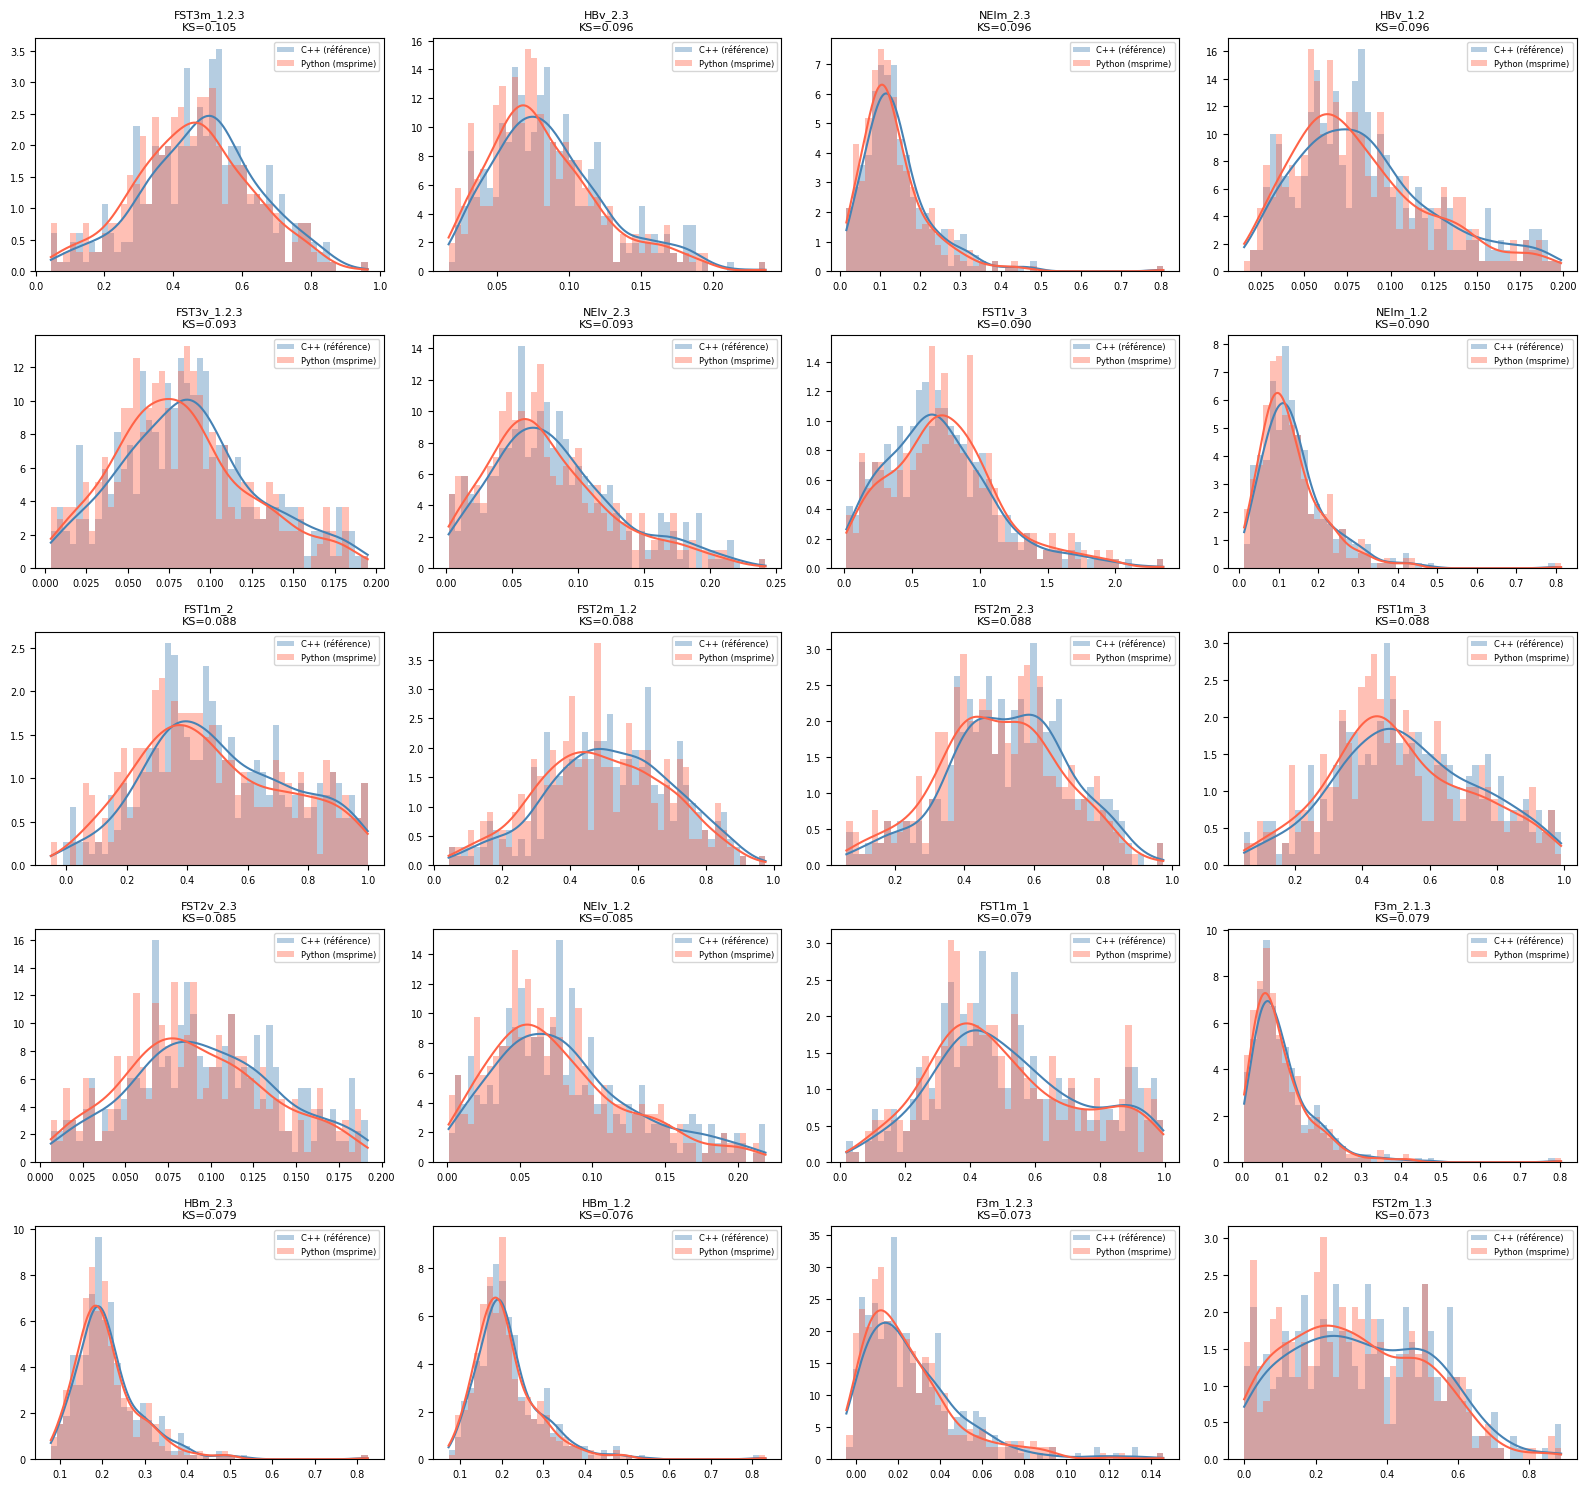

In [36]:
# Auto : top 20 colonnes les plus divergentes
TOP_N = 20
top_cols = ks_df.head(TOP_N).index.tolist()
print(f"Top {TOP_N} colonnes les plus divergentes (KS) :")
plot_comparison(top_cols)

In [37]:
# Manuel : liste de colonnes spécifiques (à adapter)
# COLS_MANUAL = ['stat_001', 'prior_Ne1', ...]
# plot_comparison(COLS_MANUAL)

## 5. Vue d'ensemble : écart relatif des moyennes

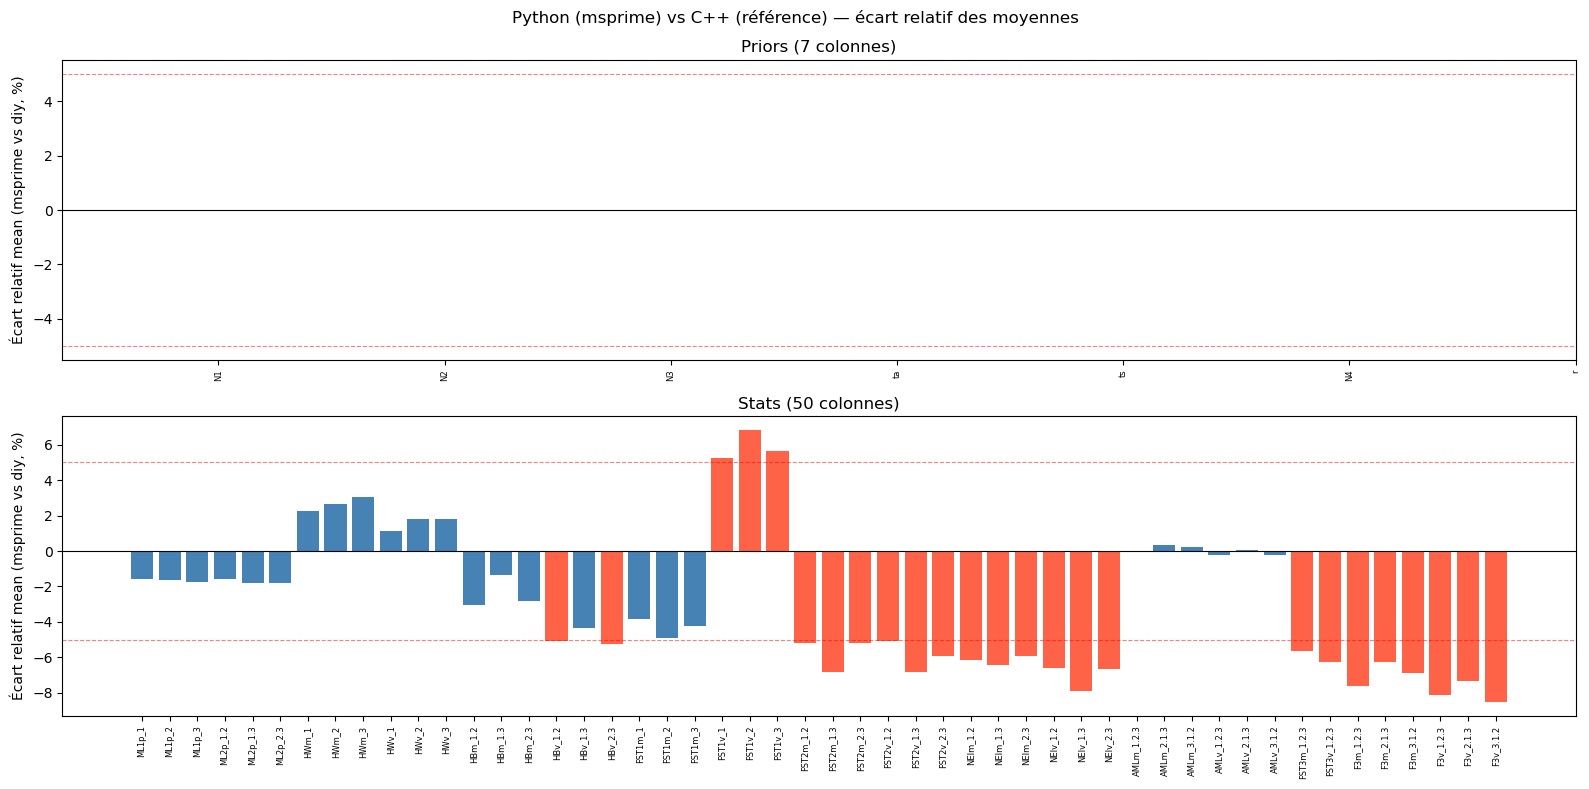

In [38]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

for ax, cols, title in [
    (axes[0], col_priors, f"Priors ({N_PRIORS} colonnes)"),
    (axes[1], col_stats, f"Stats ({N_STATS} colonnes)"),
]:
    rdiffs = desc.loc[cols, "rdiff_mean"]
    colors = ["tomato" if abs(v) > THRESHOLD_PCT else "steelblue" for v in rdiffs]
    ax.bar(range(len(rdiffs)), rdiffs.values, color=colors, width=0.8)
    ax.axhline(0, color="black", lw=0.8)
    ax.axhline(THRESHOLD_PCT, color="red", lw=0.8, ls="--", alpha=0.5)
    ax.axhline(-THRESHOLD_PCT, color="red", lw=0.8, ls="--", alpha=0.5)
    ax.set_xticks(range(len(rdiffs)))
    ax.set_xticklabels(rdiffs.index, rotation=90, fontsize=6)
    ax.set_ylabel("Écart relatif mean (msprime vs diy, %)")
    ax.set_title(title)

plt.suptitle(
    f"{LABEL_msprime} vs {LABEL_diy} — écart relatif des moyennes", fontsize=12
)
plt.tight_layout()
plt.show()

## 6. Export du résumé

In [23]:
out_path = Path("comparaison_summary.csv")
summary = desc[
    [
        "diy_mean",
        "msprime_mean",
        "diff_mean",
        "rdiff_mean",
        "diy_std",
        "msprime_std",
        "diff_std",
        "diy_5%",
        "diy_50%",
        "diy_95%",
        "msprime_5%",
        "msprime_50%",
        "msprime_95%",
    ]
].round(6)
summary = summary.join(ks_df)
summary.to_csv(out_path)
print(f"Résumé exporté → {out_path}")

Résumé exporté → comparaison_summary.csv
